# Phase 5 — Significance Testing

**Investigating Construct Validity and Stylistic Invariance in Transformer-Based Automated Essay Scoring**
Shravani Kedarnath Umbarje · Student ID 5720570 · CS907/13

---

### What this notebook does, in one sentence
Phase 4 told us *that* the models shift more under stylistic edits than under
discourse edits, and that Longformer shifts more than BERT. Phase 5 asks the
harder question: **are those patterns real, or could they be an accident of the
particular essays we happened to test?**

### Why this phase exists
Phase 4 reported single numbers — for example, "BERT's average shift under
connective edits is 0.243." A single number cannot tell you whether the pattern
would survive on a different sample of essays. This notebook attaches a
**confidence interval** and a **p-value** to every headline claim, so the
dissertation can say a result is reliable rather than just describing it.

Every later result in the project rests on this one, which is why it is done
first.

---

### Plain-English glossary (every term used below is defined here first)

- **Score shift.** For one essay, the model's score *after* an edit minus its
  score *before*. If a meaning-preserving edit changes the score, that shift is
  evidence of construct-irrelevant variance (CIV).
- **MAS (Mean Absolute Shift).** The average *size* of the score shift across
  essays, ignoring direction. Larger MAS = the model is more sensitive to that
  edit.
- **Bootstrap.** A way to estimate uncertainty by re-drawing the essays we have,
  with replacement, thousands of times and recomputing the number each time. The
  spread of those thousands of values shows how much the number would wobble on
  fresh samples.
- **95% confidence interval (CI).** The middle 95% of those bootstrap values. If
  two intervals do not overlap, the two numbers are meaningfully different.
- **Permutation test.** A way to get a p-value without assuming the data follow
  any particular bell curve. We repeatedly shuffle the labels under the
  assumption that they do not matter, and see how often pure shuffling produces a
  gap as large as the one we actually observed.
- **p-value.** The chance of seeing a gap at least as large as ours if the labels
  truly did not matter. Small p (< 0.05) means the gap is unlikely to be luck.
- **Paired test.** Because the *same* essays are scored by both models (and under
  every edit), we compare them essay-by-essay rather than as two unrelated piles.
  Pairing removes essay-to-essay noise and is the correct design here.
- **Effect size (Cohen's dz).** A p-value says whether an effect is real; the
  effect size says whether it is *big*. dz is the mean paired difference divided
  by its standard deviation.
- **Multiple-comparison correction (Holm).** Running many tests inflates the
  chance of a false positive. Holm's method tightens the threshold to keep the
  overall error rate honest. We report raw and corrected p-values side by side.

---

### Status after this notebook (completed / promised / remaining)
- **Completed here:** per-essay shift file, bootstrap CIs for all 12 MAS values,
  paired permutation tests for the two headline claims, the P6 length test,
  dissertation figures and tables.
- **Promised next:** footprint normalisation (divides each shift by the share of
  tokens changed — this notebook already flags where that matters).
- **Remaining:** CIV regression (RQ2), calibration (RQ3), fairness stratification,
  and the four innovations.

> **Runtime note.** Part A re-scores every gated essay with both models to rebuild
> the per-essay shifts. On a Kaggle GPU this takes roughly 30–45 minutes
> (Longformer is the slow part). Parts B–D are CPU-only and finish in seconds, so
> once the shift file is saved you can re-run the statistics as often as you like
> without the GPU.

## 1. Environment and GPU check

This first cell loads the libraries and confirms a GPU is switched on. If it
prints `Device: cpu`, stop and enable the GPU (see the setup guide — *Settings →
Accelerator → GPU*), because Part A would be far too slow on CPU.

In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizerFast
from transformers import LongformerModel, LongformerTokenizerFast
from transformers import logging as hf_logging
import matplotlib.pyplot as plt
import glob, os, warnings

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# One fixed seed so the bootstrap and permutation shuffles are reproducible.
# (The same seed 42 used for the data split in Phases 2 and 2b.)
SEED = 42
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if device.type == 'cuda':
    print("GPU   :", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. Enable it before running Part A.")

Device: cuda
GPU   : Tesla T4


## 2. Find the input files

Phase 5 needs the three files you already put in the `phase4-robustness` dataset:
the verified perturbations and the two trained model weights. Rather than
hard-code a path (which breaks if the dataset mounts at a slightly different
place), this cell *searches* for each file by name anywhere under
`/kaggle/input/`. If a file is missing it stops immediately with a clear message,
so you never waste GPU time on a half-loaded run.

In [17]:
def find_file(filename):
    hits = glob.glob(f'/kaggle/input/**/{filename}', recursive=True)
    if not hits:
        raise FileNotFoundError(
            f"Could not find '{filename}' under /kaggle/input/. "
            f"Add the 'phase4-robustness' dataset to this notebook (see setup guide, Step 4).")
    print(f"Found {filename}:\n   {hits[0]}")
    return hits[0]

PERT_PATH    = find_file('perturbations_verified.csv')
BERT_WEIGHTS = find_file('best_bert_aes_model.pt')
LF_WEIGHTS   = find_file('best_longformer_aes_model.pt')

Found perturbations_verified.csv:
   /kaggle/input/datasets/shravaniuk/phase-5/perturbations_verified.csv
Found best_bert_aes_model.pt:
   /kaggle/input/datasets/shravaniuk/phase-5/best_bert_aes_model.pt
Found best_longformer_aes_model.pt:
   /kaggle/input/datasets/shravaniuk/phase-5/best_longformer_aes_model.pt


## 3. Load the verified perturbation set

We reload the exact file Phase 4 used, keeping `essay_id` as text so the
scientific-notation problem from the interim report cannot reappear. The
`PERTURBATIONS` dictionary maps each perturbation to (a) the column holding the
edited essay and (b) the column that says whether that essay passed the SBERT
meaning gate. The two group lists encode the central hypothesis: **stylistic
edits should barely move a valid scorer; discourse edits should move it.**

The six perturbations, one line each:
- **P1 Lexical formality** — swaps informal wording for formal (meaning kept).
- **P2 Connective density** — inserts transition words, no new content (meaning kept).
- **P3 Syntactic voice** — flips active/passive (meaning kept).
- **P4 Discourse weakening** — replaces an Effective segment with an Ineffective one (meaning weakened *by design*).
- **P5 Structural disruption** — removes a Counterclaim or Rebuttal (meaning weakened *by design*).
- **P6 Length extension** — adds filler repeating existing points (the length counterfactual).

In [18]:
df = pd.read_csv(PERT_PATH, dtype={'essay_id': str})
print("Essays loaded:", len(df))

PERTURBATIONS = {
    'P1_lexical_formality'  : ('p1_formality',  'gate_p1'),
    'P2_connective_density' : ('p2_density',    'gate_p2'),
    'P3_syntactic_voice'    : ('p3_voice',      'gate_p3'),
    'P4_discourse_weakening': ('p4_weakening',  'gate_p4'),
    'P5_structural_disrupt' : ('p5_disruption', 'gate_p5'),
    'P6_length_extension'   : ('p6_length',     'gate_p6'),
}
STYLISTIC     = ['P1_lexical_formality', 'P2_connective_density', 'P3_syntactic_voice']
DISCOURSE     = ['P4_discourse_weakening', 'P5_structural_disrupt']
COUNTERFACT   = ['P6_length_extension']

# Human-readable group label for every perturbation (used in tables and figures).
GROUP = {p: 'Stylistic'      for p in STYLISTIC}
GROUP.update({p: 'Discourse' for p in DISCOURSE})
GROUP.update({p: 'Counterfactual' for p in COUNTERFACT})

# Make sure the gate columns are genuine True/False, not the strings "True"/"False".
for _, gate in PERTURBATIONS.values():
    if df[gate].dtype != bool:
        df[gate] = df[gate].astype(str).str.strip().str.lower().map(
            {'true': True, 'false': False}).fillna(False)

for name, (col, gate) in PERTURBATIONS.items():
    print(f"{name:26s} gated essays: {int(df[gate].sum())}")

Essays loaded: 15594
P1_lexical_formality       gated essays: 15368
P2_connective_density      gated essays: 15456
P3_syntactic_voice         gated essays: 12224
P4_discourse_weakening     gated essays: 1595
P5_structural_disrupt      gated essays: 3926
P6_length_extension        gated essays: 15456


## 4. Model definitions and scoring functions (identical to Phase 4)

These classes and functions are copied **verbatim** from the Phase 4 audit. That
is deliberate: reusing the exact scoring code is what guarantees Phase 5
reproduces the Phase 4 numbers to the decimal, which we check at the end of Part
A. Both models are regressors: they output a number in the normalised range, and
we convert it back to the 1–6 essay scale with `score * 5 + 1`.

- **BERT** reads 512 tokens using head-and-tail truncation (keeps the opening 128
  and the closing tokens, where argument and conclusion usually sit).
- **Longformer** reads up to 1,024 tokens directly, with global attention on the
  first token (the position whose hidden state feeds the regression head).

In [19]:
class BERTEssayScorer(nn.Module):
    def __init__(self, name='bert-base-uncased', dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(name)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.bert.config.hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.regressor(self.dropout(out.last_hidden_state[:, 0, :])).squeeze(-1)


class LongformerEssayScorer(nn.Module):
    def __init__(self, name='allenai/longformer-base-4096', dropout=0.3):
        super().__init__()
        self.longformer = LongformerModel.from_pretrained(name)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.longformer.config.hidden_size, 1)
    def forward(self, input_ids, attention_mask, global_attention_mask):
        out = self.longformer(input_ids=input_ids, attention_mask=attention_mask,
                              global_attention_mask=global_attention_mask)
        return self.regressor(self.dropout(out.last_hidden_state[:, 0, :])).squeeze(-1)


def head_tail_encode(text, tok, max_len=512, head=128):
    tail = max_len - head
    ids = tok.encode(str(text), add_special_tokens=False, truncation=False)
    if len(ids) <= max_len - 2:
        enc = tok(str(text), max_length=max_len, padding='max_length',
                  truncation=True, return_tensors='pt')
        return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)
    combined = ids[:head - 1] + ids[-(tail - 1):]
    input_ids = [tok.cls_token_id] + combined + [tok.sep_token_id]
    pad = [tok.pad_token_id] * (max_len - len(input_ids))
    attn = [1] * len(input_ids) + [0] * len(pad)
    return torch.tensor(input_ids + pad), torch.tensor(attn)


@torch.no_grad()
def score_bert(model, tok, texts, batch=32):
    model.eval(); preds = []
    for i in range(0, len(texts), batch):
        chunk = texts[i:i+batch]
        enc = [head_tail_encode(t, tok) for t in chunk]
        ids = torch.stack([e[0] for e in enc]).to(device)
        am  = torch.stack([e[1] for e in enc]).to(device)
        out = model(ids, am).cpu().numpy()
        preds.extend((out * 5 + 1).tolist())
    return np.clip(np.array(preds), 1, 6)


@torch.no_grad()
def score_longformer(model, tok, texts, batch=8, max_len=1024):
    model.eval(); preds = []
    for i in range(0, len(texts), batch):
        chunk = [str(t) for t in texts[i:i+batch]]
        enc = tok(chunk, max_length=max_len, padding='max_length',
                  truncation=True, return_tensors='pt')
        ids = enc['input_ids'].to(device)
        am  = enc['attention_mask'].to(device)
        gam = torch.zeros_like(am); gam[:, 0] = 1
        out = model(ids, am, gam).cpu().numpy()
        preds.extend((out * 5 + 1).tolist())
    return np.clip(np.array(preds), 1, 6)

print("Model classes and scoring functions ready.")

Model classes and scoring functions ready.


## Part A — Rebuild the per-essay shifts

### 5. Why we regenerate, and what we save

Phase 4 calculated each essay's shift but only saved the *average* (MAS). A
bootstrap resamples individual essays, and a paired permutation test flips
individual essays' signs — both need the **one row per essay per perturbation**
table that Phase 4 never stored. So we rebuild it once here.

For each perturbation we follow Phase 4's masking exactly: keep an essay only if
it (a) passed the meaning gate, (b) actually has an edited version, and (c) the
edit genuinely changed the text. We score the originals once per model, then the
perturbed versions, and record the shift for every essay. The result is saved as
`phase5_per_essay_shifts.csv`, a file later phases (footprint normalisation, the
CIV regression, the decomposition) will reuse.

In [20]:
def collect_shifts(score_fn, model, tok, df, model_label):
    """Return one row per (essay, perturbation): the original score, the
    perturbed score, and their difference. Mirrors Phase 4's run_audit masking
    exactly so the averaged numbers reproduce."""
    # Score every original once, reuse across all six perturbations.
    orig_scores = score_fn(model, tok, df['original'].tolist())
    orig_by_idx = pd.Series(orig_scores, index=df.index)

    rows = []
    for name, (col, gate) in PERTURBATIONS.items():
        mask = (df[gate] == True) & df[col].notna() & (df[col] != df['original'])
        sub = df[mask]
        if len(sub) == 0:
            continue
        pert_scores = score_fn(model, tok, sub[col].tolist())
        base_scores = orig_by_idx.loc[sub.index].values
        shift = pert_scores - base_scores

        block = pd.DataFrame({
            'essay_id'    : sub['essay_id'].values,
            'true_score'  : sub['score'].values,
            'model'       : model_label,
            'perturbation': name,
            'group'       : GROUP[name],
            'orig_score'  : base_scores,
            'pert_score'  : pert_scores,
            'shift'       : shift,
            'abs_shift'   : np.abs(shift),
        })
        rows.append(block)
        print(f"  {model_label:10s} {name:26s} n={len(sub):6d}  "
              f"MAS={np.mean(np.abs(shift)):.4f}")
    return pd.concat(rows, ignore_index=True)

### 5a. BERT — collect per-essay shifts
This loads the trained BERT weights and scores every gated essay. Watch the
printed MAS values: they should match the Phase 4 table (P1≈0.049, P2≈0.243,
P3≈0.192, P4≈0.137, P5≈0.092, P6≈0.293).

In [21]:
bert_model = BERTEssayScorer().to(device)
bert_model.load_state_dict(torch.load(BERT_WEIGHTS, map_location=device))
bert_tok = BertTokenizerFast.from_pretrained('bert-base-uncased')

print("Collecting BERT per-essay shifts...")
bert_shifts = collect_shifts(score_bert, bert_model, bert_tok, df, 'BERT')

# Free the GPU before loading the second model.
del bert_model; torch.cuda.empty_cache()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  BERT       P1_lexical_formality       n= 15368  MAS=0.0492
  BERT       P2_connective_density      n= 15456  MAS=0.2428
  BERT       P3_syntactic_voice         n= 12224  MAS=0.1919
  BERT       P4_discourse_weakening     n=  1595  MAS=0.1371
  BERT       P5_structural_disrupt      n=  3926  MAS=0.0915
  BERT       P6_length_extension        n= 15456  MAS=0.2930


### 5b. Longformer — collect per-essay shifts
Same again for Longformer. Expected MAS: P1≈0.047, P2≈0.200, **P3≈0.466** (the
headline single-perturbation result), P4≈0.126, P5≈0.093, P6≈0.171. This is the
slow cell.

In [22]:
lf_model = LongformerEssayScorer().to(device)
lf_model.load_state_dict(torch.load(LF_WEIGHTS, map_location=device))
lf_tok = LongformerTokenizerFast.from_pretrained('allenai/longformer-base-4096')

print("Collecting Longformer per-essay shifts...")
lf_shifts = collect_shifts(score_longformer, lf_model, lf_tok, df, 'Longformer')

del lf_model; torch.cuda.empty_cache()

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Longformer P1_lexical_formality       n= 15368  MAS=0.0467
  Longformer P2_connective_density      n= 15456  MAS=0.1995
  Longformer P3_syntactic_voice         n= 12224  MAS=0.4658
  Longformer P4_discourse_weakening     n=  1595  MAS=0.1258
  Longformer P5_structural_disrupt      n=  3926  MAS=0.0931
  Longformer P6_length_extension        n= 15456  MAS=0.1706


### 5c. Combine, save, and verify reproducibility
We stack the two models' shifts into one long table and save it. The verification
step recomputes MAS from these per-essay rows and compares it against the Phase 4
figures — if any value drifts by more than 0.001 it prints a warning. Because
scoring runs in `eval` mode (dropout off), the match should be exact.

In [23]:
shifts = pd.concat([bert_shifts, lf_shifts], ignore_index=True)
shifts.to_csv('phase5_per_essay_shifts.csv', index=False)
print("Saved phase5_per_essay_shifts.csv  |  rows:", len(shifts))

# Reproducibility check against the Phase 4 results table.
phase4_MAS = {
    ('BERT','P1_lexical_formality'):0.0492, ('BERT','P2_connective_density'):0.2428,
    ('BERT','P3_syntactic_voice'):0.1919,   ('BERT','P4_discourse_weakening'):0.1371,
    ('BERT','P5_structural_disrupt'):0.0915,('BERT','P6_length_extension'):0.293,
    ('Longformer','P1_lexical_formality'):0.0467,('Longformer','P2_connective_density'):0.1995,
    ('Longformer','P3_syntactic_voice'):0.4658, ('Longformer','P4_discourse_weakening'):0.1258,
    ('Longformer','P5_structural_disrupt'):0.0931,('Longformer','P6_length_extension'):0.1706,
}
print("\nReproducibility check (recomputed vs Phase 4):")
ok = True
for (m, p), ref in phase4_MAS.items():
    got = shifts[(shifts.model==m) & (shifts.perturbation==p)]['abs_shift'].mean()
    flag = "OK" if abs(got - ref) < 1e-3 else "*** MISMATCH ***"
    if flag != "OK": ok = False
    print(f"  {m:10s} {p:26s} recomputed={got:.4f}  phase4={ref:.4f}  {flag}")
print("\nAll values reproduce." if ok else "\nSome values differ — investigate before continuing.")

Saved phase5_per_essay_shifts.csv  |  rows: 128050

Reproducibility check (recomputed vs Phase 4):
  BERT       P1_lexical_formality       recomputed=0.0492  phase4=0.0492  OK
  BERT       P2_connective_density      recomputed=0.2428  phase4=0.2428  OK
  BERT       P3_syntactic_voice         recomputed=0.1919  phase4=0.1919  OK
  BERT       P4_discourse_weakening     recomputed=0.1371  phase4=0.1371  OK
  BERT       P5_structural_disrupt      recomputed=0.0915  phase4=0.0915  OK
  BERT       P6_length_extension        recomputed=0.2930  phase4=0.2930  OK
  Longformer P1_lexical_formality       recomputed=0.0467  phase4=0.0467  OK
  Longformer P2_connective_density      recomputed=0.1995  phase4=0.1995  OK
  Longformer P3_syntactic_voice         recomputed=0.4658  phase4=0.4658  OK
  Longformer P4_discourse_weakening     recomputed=0.1258  phase4=0.1258  OK
  Longformer P5_structural_disrupt      recomputed=0.0931  phase4=0.0931  OK
  Longformer P6_length_extension        recomputed=0.1

## Part B — Statistics (CPU-only from here)

### 6. Bootstrap confidence intervals for every MAS

For each of the 12 (model × perturbation) cells we resample the essays with
replacement `B` times, recompute MAS each time, and take the 2.5th and 97.5th
percentiles as the 95% interval. A narrow interval that sits well above zero
means the sensitivity is both real and precisely estimated.

In [25]:
def bootstrap_mas_ci(abs_shifts, B=10000, seed=SEED):
    """95% percentile bootstrap CI for the mean of |shift|."""
    rng = np.random.default_rng(seed)
    x = np.asarray(abs_shifts, dtype=float)
    n = len(x)
    means = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)          # sample n essays with replacement
        means[b] = x[idx].mean()
    lo, hi = np.percentile(means, [2.5, 97.5])
    return x.mean(), lo, hi

boot_rows = []
for m in ['BERT', 'Longformer']:
    for p in PERTURBATIONS:
        sub = shifts[(shifts.model == m) & (shifts.perturbation == p)]['abs_shift'].values
        if len(sub) == 0:
            continue
        mas, lo, hi = bootstrap_mas_ci(sub)
        boot_rows.append({'model': m, 'perturbation': p, 'group': GROUP[p],
                          'n': len(sub), 'MAS': round(mas, 4),
                          'CI_low': round(lo, 4), 'CI_high': round(hi, 4)})

boot = pd.DataFrame(boot_rows)
print(boot.to_string(index=False))

     model           perturbation          group     n    MAS  CI_low  CI_high
      BERT   P1_lexical_formality      Stylistic 15368 0.0492  0.0484   0.0501
      BERT  P2_connective_density      Stylistic 15456 0.2428  0.2399   0.2457
      BERT     P3_syntactic_voice      Stylistic 12224 0.1919  0.1879   0.1960
      BERT P4_discourse_weakening      Discourse  1595 0.1371  0.1278   0.1464
      BERT  P5_structural_disrupt      Discourse  3926 0.0915  0.0873   0.0960
      BERT    P6_length_extension Counterfactual 15456 0.2930  0.2899   0.2960
Longformer   P1_lexical_formality      Stylistic 15368 0.0467  0.0458   0.0476
Longformer  P2_connective_density      Stylistic 15456 0.1995  0.1971   0.2018
Longformer     P3_syntactic_voice      Stylistic 12224 0.4658  0.4612   0.4705
Longformer P4_discourse_weakening      Discourse  1595 0.1258  0.1191   0.1327
Longformer  P5_structural_disrupt      Discourse  3926 0.0931  0.0903   0.0959
Longformer    P6_length_extension Counterfactual 154

### 7. Paired permutation test — BERT vs Longformer, per perturbation

The same essays are scored by both models, so we compare them essay-by-essay.
For each essay we take `d = |Longformer shift| − |BERT shift|`. Under the null
hypothesis "the model label does not matter", the sign of each `d` is arbitrary,
so we build a null distribution by randomly flipping signs many times. The
p-value is how often a purely random flip produces a mean as extreme as the one
we actually see. We also report **dz** (effect size) and apply **Holm**
correction across the six tests.

The key row to watch is **P3**: Phase 4 showed Longformer shifting far more than
BERT (0.466 vs 0.192). This test says whether that gap is trustworthy.

In [26]:
def paired_sign_flip(d, B=10000, seed=SEED):
    """Two-sided paired permutation test by random sign-flips.
    Returns (mean difference, p-value, Cohen's dz)."""
    rng = np.random.default_rng(seed)
    d = np.asarray(d, dtype=float)
    n = len(d)
    obs = d.mean()
    count = 0
    for _ in range(B):
        signs = rng.choice([-1.0, 1.0], size=n)
        if abs((d * signs).mean()) >= abs(obs):
            count += 1
    p = (count + 1) / (B + 1)                 # +1 keeps p strictly > 0
    dz = obs / d.std(ddof=1) if d.std(ddof=1) > 0 else np.nan
    return obs, p, dz

def holm(pvals):
    """Holm-Bonferroni adjusted p-values."""
    order = np.argsort(pvals)
    m = len(pvals)
    adj = np.empty(m)
    running = 0.0
    for rank, i in enumerate(order):
        val = (m - rank) * pvals[i]
        running = max(running, val)
        adj[i] = min(running, 1.0)
    return adj

rows, praw = [], []
for p in PERTURBATIONS:
    b = shifts[(shifts.model=='BERT')       & (shifts.perturbation==p)][['essay_id','abs_shift']]
    l = shifts[(shifts.model=='Longformer') & (shifts.perturbation==p)][['essay_id','abs_shift']]
    merged = b.merge(l, on='essay_id', suffixes=('_bert','_lf'))
    d = merged['abs_shift_lf'].values - merged['abs_shift_bert'].values
    obs, pval, dz = paired_sign_flip(d)
    rows.append({'perturbation': p, 'n_paired': len(d),
                 'mean_LF_minus_BERT': round(obs, 4),
                 'dz': round(dz, 3), 'p_raw': pval})
    praw.append(pval)

bvl = pd.DataFrame(rows)
bvl['p_holm'] = np.round(holm(np.array(praw)), 4)
bvl['p_raw']  = np.round(bvl['p_raw'], 4)
bvl['significant_5pct'] = bvl['p_holm'] < 0.05
print(bvl.to_string(index=False))

          perturbation  n_paired  mean_LF_minus_BERT     dz  p_raw  p_holm  significant_5pct
  P1_lexical_formality     15368             -0.0025 -0.037 0.0001  0.0006              True
 P2_connective_density     15456             -0.0434 -0.179 0.0001  0.0006              True
    P3_syntactic_voice     12224              0.2739  1.096 0.0001  0.0006              True
P4_discourse_weakening      1595             -0.0113 -0.068 0.0068  0.0136              True
 P5_structural_disrupt      3926              0.0016  0.012 0.4564  0.4564             False
   P6_length_extension     15456             -0.1224 -0.674 0.0001  0.0006              True


### 8. Paired permutation test — stylistic vs discourse (the headline claim)

This is the central result of the whole project: **do the models move more under
meaning-preserving stylistic edits than under argument-weakening discourse
edits?** We test it per model, paired within essays.

For each essay we compute its average sensitivity to stylistic edits (mean
`|shift|` over the P1–P3 it passed) and its average sensitivity to discourse
edits (mean over the P4–P5 it passed), keeping only essays that have at least one
of each so the comparison is genuinely paired. Then the same sign-flip
permutation test asks whether the stylistic-minus-discourse gap is real.

In [27]:
def per_essay_group_means(model_label):
    """For one model, return a table with each essay's mean |shift| over
    stylistic edits and over discourse edits (essays having at least one of each)."""
    sub = shifts[shifts.model == model_label]
    sty = (sub[sub.perturbation.isin(STYLISTIC)]
           .groupby('essay_id')['abs_shift'].mean().rename('stylistic'))
    dis = (sub[sub.perturbation.isin(DISCOURSE)]
           .groupby('essay_id')['abs_shift'].mean().rename('discourse'))
    both = pd.concat([sty, dis], axis=1).dropna()
    return both

sd_rows, sd_praw = [], []
for m in ['BERT', 'Longformer']:
    both = per_essay_group_means(m)
    d = both['stylistic'].values - both['discourse'].values
    obs, pval, dz = paired_sign_flip(d)
    sd_rows.append({'model': m, 'n_paired_essays': len(d),
                    'mean_stylistic': round(both['stylistic'].mean(), 4),
                    'mean_discourse': round(both['discourse'].mean(), 4),
                    'gap_style_minus_disc': round(obs, 4),
                    'dz': round(dz, 3), 'p_raw': pval})
    sd_praw.append(pval)

styvsdisc = pd.DataFrame(sd_rows)
styvsdisc['p_holm'] = np.round(holm(np.array(sd_praw)), 4)
styvsdisc['p_raw']  = np.round(styvsdisc['p_raw'], 4)
styvsdisc['significant_5pct'] = styvsdisc['p_holm'] < 0.05
print(styvsdisc.to_string(index=False))

     model  n_paired_essays  mean_stylistic  mean_discourse  gap_style_minus_disc    dz  p_raw  p_holm  significant_5pct
      BERT             4986          0.1617          0.1029                0.0588 0.360 0.0001  0.0002              True
Longformer             4986          0.2396          0.1006                0.1389 0.898 0.0001  0.0002              True


### 9. Is the P6 length association significant?

The P6 counterfactual adds filler that repeats existing points, holding argument
quality roughly constant while increasing length. Phase 4 found a positive
*signed* shift (scores go up). Here we bootstrap a 95% CI for that signed shift.
If the interval lies entirely above zero, the length association is statistically
reliable — reported,strictly as an
**association**, never as "length causes higher scores".

In [28]:
def bootstrap_signed_ci(signed, B=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    x = np.asarray(signed, dtype=float); n = len(x)
    means = np.empty(B)
    for b in range(B):
        means[b] = x[rng.integers(0, n, n)].mean()
    lo, hi = np.percentile(means, [2.5, 97.5])
    return x.mean(), lo, hi

print("P6 length extension — signed shift (positive = score rose):\n")
p6_rows = []
for m in ['BERT', 'Longformer']:
    s = shifts[(shifts.model==m) & (shifts.perturbation=='P6_length_extension')]['shift'].values
    mean, lo, hi = bootstrap_signed_ci(s)
    excludes_zero = lo > 0 or hi < 0
    p6_rows.append({'model': m, 'signed_shift': round(mean,4),
                    'CI_low': round(lo,4), 'CI_high': round(hi,4),
                    'CI_excludes_0': excludes_zero})
p6 = pd.DataFrame(p6_rows)
print(p6.to_string(index=False))
print("\nReading: a CI entirely above 0 means the positive length-score "
      "association is reliable on this sample (reported as association, not cause).")

P6 length extension — signed shift (positive = score rose):

     model  signed_shift  CI_low  CI_high  CI_excludes_0
      BERT        0.2850  0.2818   0.2882           True
Longformer        0.1687  0.1672   0.1703           True

Reading: a CI entirely above 0 means the positive length-score association is reliable on this sample (reported as association, not cause).


## Part C — Dissertation figure and tables

### 10. MAS with 95% confidence intervals

This upgrades the Phase 4 bar chart by adding error bars. Where Phase 4 showed
bare bars, the examiner now sees the uncertainty on each one. Stylistic bars are
green, discourse red, and the counterfactual blue, matching the interim's colour
scheme. Saved as `fig_phase5_mas_ci.png` for the dissertation.

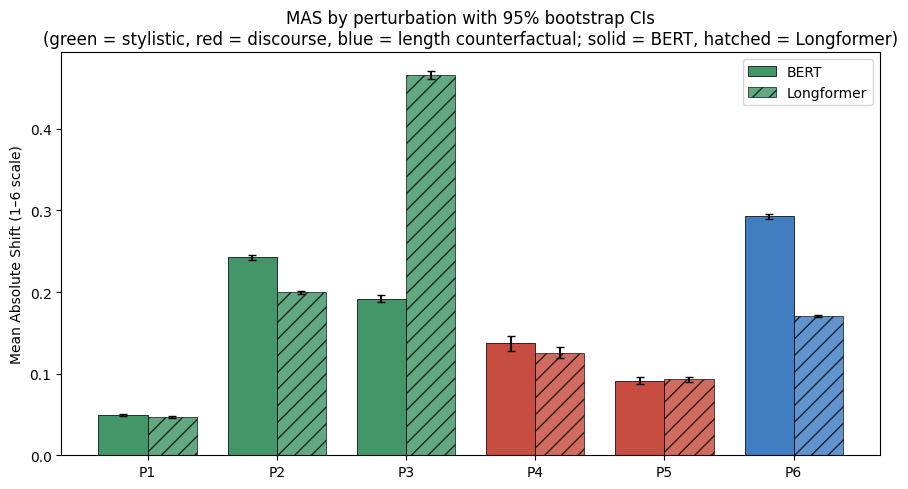

Saved fig_phase5_mas_ci.png


In [29]:
order = list(PERTURBATIONS.keys())
labels = ['P1','P2','P3','P4','P5','P6']
colour = {'Stylistic':'#2e8b57', 'Discourse':'#c0392b', 'Counterfactual':'#2c6fbb'}

fig, ax = plt.subplots(figsize=(9, 5))
width = 0.38
for k, m in enumerate(['BERT', 'Longformer']):
    xs, ys, lo_err, hi_err, cols = [], [], [], [], []
    for j, p in enumerate(order):
        r = boot[(boot.model==m) & (boot.perturbation==p)]
        if r.empty: continue
        r = r.iloc[0]
        xs.append(j + (k-0.5)*width); ys.append(r['MAS'])
        lo_err.append(r['MAS']-r['CI_low']); hi_err.append(r['CI_high']-r['MAS'])
        cols.append(colour[r['group']])
    hatch = '' if m=='BERT' else '//'
    ax.bar(xs, ys, width, yerr=[lo_err, hi_err], capsize=3,
           color=cols, edgecolor='black', linewidth=0.6, hatch=hatch,
           label=m, alpha=0.9 if m=='BERT' else 0.75)

ax.set_xticks(range(len(order))); ax.set_xticklabels(labels)
ax.set_ylabel('Mean Absolute Shift (1–6 scale)')
ax.set_title('MAS by perturbation with 95% bootstrap CIs\n'
             '(green = stylistic, red = discourse, blue = length counterfactual; '
             'solid = BERT, hatched = Longformer)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('fig_phase5_mas_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_phase5_mas_ci.png")

### 11. Save every result table (CSV + LaTeX)

In [30]:
# --- CSVs -------------------------------------------------------------
boot.to_csv('phase5_bootstrap_cis.csv', index=False)
bvl.to_csv('phase5_bert_vs_longformer.csv', index=False)
styvsdisc.to_csv('phase5_stylistic_vs_discourse.csv', index=False)
p6.to_csv('phase5_p6_length_ci.csv', index=False)
print("Saved 4 result CSVs.")

# --- LaTeX: bootstrap CI table ---------------------------------------
def latex_bootstrap(boot):
    lines = [r"\begin{tabular}{llrrr}", r"\toprule",
             r"Model & Perturbation & $n$ & MAS & 95\% CI \\", r"\midrule"]
    for _, r in boot.iterrows():
        pert = r['perturbation'].replace('_',' ')
        lines.append(f"{r['model']} & {pert} & {r['n']} & {r['MAS']:.3f} & "
                     f"[{r['CI_low']:.3f}, {r['CI_high']:.3f}] \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    return "\n".join(lines)

with open('table_phase5_bootstrap.tex', 'w') as f:
    f.write(latex_bootstrap(boot))

# --- LaTeX: headline stylistic-vs-discourse table --------------------
def latex_styvsdisc(t):
    lines = [r"\begin{tabular}{lrrrrrl}", r"\toprule",
             r"Model & $n$ & Stylistic & Discourse & Gap & $d_z$ & $p_{\text{Holm}}$ \\",
             r"\midrule"]
    for _, r in t.iterrows():
        lines.append(f"{r['model']} & {r['n_paired_essays']} & {r['mean_stylistic']:.3f} & "
                     f"{r['mean_discourse']:.3f} & {r['gap_style_minus_disc']:.3f} & "
                     f"{r['dz']:.2f} & {r['p_holm']:.4f} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    return "\n".join(lines)

with open('table_phase5_styvsdisc.tex', 'w') as f:
    f.write(latex_styvsdisc(styvsdisc))

print("Saved 2 LaTeX tables (table_phase5_bootstrap.tex, table_phase5_styvsdisc.tex).")

Saved 4 result CSVs.
Saved 2 LaTeX tables (table_phase5_bootstrap.tex, table_phase5_styvsdisc.tex).
